# Bước 1: Tiền xử lý dữ liệu & Giảm chiều PCA

Notebook này thực hiện việc làm sạch dữ liệu, điền khuyết, mã hóa đặc trưng, chuẩn hóa và giảm chiều bằng PCA. Dữ liệu sạch sau đó sẽ được lưu trữ để phục vụ huấn luyện mô hình phân cụm.

## 1. Khai báo thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Tải tập dữ liệu thô

In [2]:
# Tải tập dữ liệu huấn luyện thô
df = pd.read_csv('../data/raw/Train.csv')
print(f"Kích thước dữ liệu: {df.shape}")
df.head()

Kích thước dữ liệu: (8068, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 3. Khảo sát dữ liệu sơ bộ (EDA)

In [3]:
# Xem thông tin các cột
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [4]:
# Tính toán tỷ lệ giá trị thiếu
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print("Tỷ lệ khuyết thiếu (%):\n", missing_pct)

Tỷ lệ khuyết thiếu (%):
 ID                  0.00
Gender              0.00
Ever_Married        1.74
Age                 0.00
Graduated           0.97
Profession          1.54
Work_Experience    10.28
Spending_Score      0.00
Family_Size         4.15
Var_1               0.94
Segmentation        0.00
dtype: float64


## 4. Pipeline tiền xử lý dữ liệu

In [5]:
# Loại bỏ cột định danh ID và tách nhãn Segmentation phục vụ đối chiếu sau này
X = df.drop(columns=['ID', 'Segmentation', 'Var_1'])
y = df['Segmentation']

print(f"Kích thước ma trận đặc trưng X: {X.shape}")
print(f"Kích thước nhãn y: {y.shape}")

Kích thước ma trận đặc trưng X: (8068, 9)
Kích thước nhãn y: (8068,)


In [6]:
# Định nghĩa các nhóm đặc trưng
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']
nominal_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession']
ordinal_cols = ['Spending_Score']

# Thứ tự mã hóa cho biến Spending_Score
spending_score_order = ['Low', 'Average', 'High']

# Xây dựng Pipeline cho từng nhóm đặc trưng
num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

nom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[spending_score_order])),
    ('scaler', StandardScaler())
])

# Gộp các pipeline bằng ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('nom', nom_pipeline, nominal_cols),
    ('ord', ord_pipeline, ordinal_cols)
])

# Khớp và chuyển đổi dữ liệu thô X
X_preprocessed = preprocessor.fit_transform(X)

# Lấy tên các đặc trưng sau tiền xử lý để dựng DataFrame
nom_encoder = preprocessor.named_transformers_['nom'].named_steps['encoder']
nom_feature_names = nom_encoder.get_feature_names_out(nominal_cols).tolist()
feature_names = numerical_cols + nom_feature_names + ordinal_cols

df_preprocessed = pd.DataFrame(X_preprocessed, columns=feature_names)
print(f"Kích thước dữ liệu sạch: {df_preprocessed.shape}")
df_preprocessed.head()

Kích thước dữ liệu sạch: (8068, 26)


,Age,Work_Experience,Family_Size,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Graduated_No,Graduated_Yes,Profession_Artist,...,Profession_Lawyer,Profession_Marketing,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,Spending_Score
0,-1.284623,-0.499892,0.757947,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.736833
1,-0.327151,0.537954,0.096095,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.612411
2,1.408268,-0.499892,-1.227610,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.736833
3,1.408268,-0.805141,-0.565758,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.961655
4,-0.207467,1.453700,2.081652,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.961655


## 5. Giảm chiều dữ liệu bằng PCA

Tỷ lệ phương sai giải thích bởi 2 thành phần chính: [0.27556244 0.17343466]
Tổng phương sai được giải thích: 0.4490


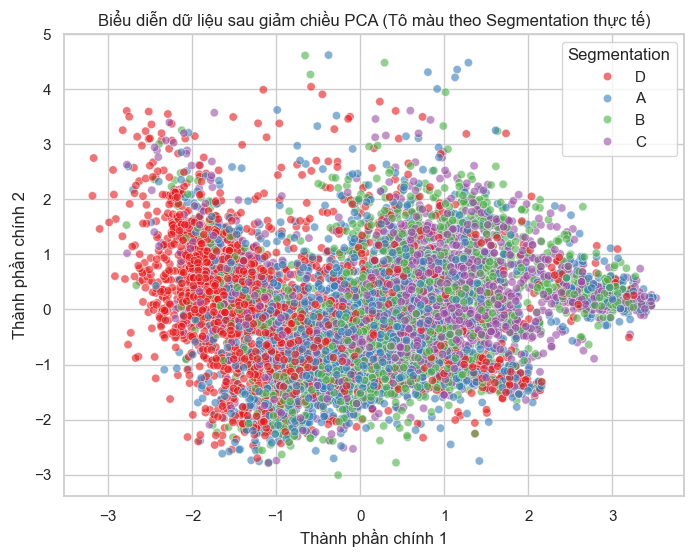

In [7]:
# Khởi tạo PCA 2 thành phần chính để kiểm tra độ phân tách cụm
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_preprocessed)

print(f"Tỷ lệ phương sai giải thích bởi 2 thành phần chính: {pca.explained_variance_ratio_}")
print(f"Tổng phương sai được giải thích: {np.sum(pca.explained_variance_ratio_):.4f}")

# Trực quan hóa dữ liệu trên không gian PCA 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', alpha=0.6)
plt.title('Biểu diễn dữ liệu sau giảm chiều PCA (Tô màu theo Segmentation thực tế)')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.show()

## 6. Lưu trữ dữ liệu sạch và các Pipelines

In [8]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs('data/ready_for_train', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Lưu trữ dữ liệu sạch
joblib.dump(X_preprocessed, 'data/ready_for_train/X_preprocessed.pkl')
joblib.dump(y, 'data/ready_for_train/y.pkl')

# Lưu trữ các bộ biến đổi
joblib.dump(preprocessor, 'models/preprocessor.pkl')
joblib.dump(pca, 'models/pca_transformer.pkl')

print("Dữ liệu sạch và các pipelines đã được lưu trữ thành công!")

Dữ liệu sạch và các pipelines đã được lưu trữ thành công!
